In [1]:
# 1: DATA LOADING & EXPLORATION
#importing libraries
import pandas as pd          
import numpy as np           
import matplotlib.pyplot as plt  
import seaborn as sns        
import warnings              
warnings.filterwarnings('ignore')  # suppress warnings so output stays clean

In [7]:
#loading the dataset
df = pd.read_csv('delhiaqi.csv')

print("       DELHI AQI DATASET - INITIAL EXPLORATION")


       DELHI AQI DATASET - INITIAL EXPLORATION


In [9]:
#Structure of the dataset
print("Shape of Dataset")

print(f"  Rows: {df.shape[0]}, Column:{df.shape[1]}")

print("\n[2] COLUMN NAMES:")

print("   ", list(df.columns))
 
print("\n[3] FIRST 5 ROWS (Head):")

print(df.head())
 
print("\n[4] DATA TYPES OF EACH COLUMN:")

print(df.dtypes)
 
print("\n[5] MISSING VALUES CHECK:")

print(df.isnull().sum())
 

Shape of Dataset
  Rows: 561, Column:9

[2] COLUMN NAMES:
    ['date', 'co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

[3] FIRST 5 ROWS (Head):
                  date       co     no    no2    o3    so2   pm2_5    pm10  \
0  2023-01-01 00:00:00  1655.58   1.66  39.41  5.90  17.88  169.29  194.64   
1  2023-01-01 01:00:00  1869.20   6.82  42.16  1.99  22.17  182.84  211.08   
2  2023-01-01 02:00:00  2510.07  27.72  43.87  0.02  30.04  220.25  260.68   
3  2023-01-01 03:00:00  3150.94  55.43  44.55  0.85  35.76  252.90  304.12   
4  2023-01-01 04:00:00  3471.37  68.84  45.24  5.45  39.10  266.36  322.80   

     nh3  
0   5.83  
1   7.66  
2  11.40  
3  13.55  
4  14.19  

[4] DATA TYPES OF EACH COLUMN:
date      object
co       float64
no       float64
no2      float64
o3       float64
so2      float64
pm2_5    float64
pm10     float64
nh3      float64
dtype: object

[5] MISSING VALUES CHECK:
date     0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     

In [15]:
#converting The Date Column
df['date'] = pd.to_datetime(df['date'])
# Extracting individual time components 
df['hour']  = df['date'].dt.hour   # 0–23 (hour of day)
df['day']   = df['date'].dt.day    # 1–31 (day of month)
df['month'] = df['date'].dt.month  # 1–12 (month number)
print("\n[6] DATE RANGE IN DATASET:")
print(f"    From: {df['date'].min()}")
print(f"    To  : {df['date'].max()}")
print(f"    Total Hours Recorded: {len(df)}")


[6] DATE RANGE IN DATASET:
    From: 2023-01-01 00:00:00
    To  : 2023-01-24 08:00:00
    Total Hours Recorded: 561


In [17]:
#Descriptive Statistics
print("\n[7] DESCRIPTIVE STATISTICS FOR ALL POLLUTANTS:")
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']
print(df[pollutants].describe().round(2))


[7] DESCRIPTIVE STATISTICS FOR ALL POLLUTANTS:
             co      no     no2      o3     so2    pm2_5     pm10     nh3
count    561.00  561.00  561.00  561.00  561.00   561.00   561.00  561.00
mean    3814.94   51.18   75.29   30.14   64.66   358.26   420.99   26.43
std     3227.74   83.90   42.47   39.98   61.07   227.36   271.29   36.56
min      654.22    0.00   13.37    0.00    5.25    60.10    69.08    0.63
25%     1708.98    3.38   44.55    0.07   28.13   204.45   240.90    8.23
50%     2590.18   13.30   63.75   11.80   47.21   301.17   340.90   14.82
75%     4432.68   59.01   97.33   47.21   77.25   416.65   482.57   26.35
max    16876.22  425.58  263.21  164.51  511.17  1310.20  1499.27  267.51


In [19]:
#calculating AQI
def calculate_aqi_pm25(pm25):
    
    # Each row is: [C_low, C_high, AQI_low, AQI_high]
    # These are the official India CPCB PM2.5 breakpoints
    breakpoints = [
        (0, 30, 0, 50),
        (30, 60, 51, 100),
        (60, 90, 101, 200),
        (90, 120, 201, 300),
        (120, 250, 301, 400),
        (250, 500, 401, 500)
    ]
    for c_low, c_high, aqi_low, aqi_high in breakpoints:
        if c_low <= pm25 <= c_high:
            # Linear interpolation formula between breakpoints
            aqi = ((aqi_high - aqi_low) / (c_high - c_low)) * (pm25 - c_low) + aqi_low
            return round(aqi, 2)
    return 500  # If PM2.5 exceeds all ranges, cap at 500
 
# Apply the function to every row in the dataset
# .apply() runs a function on each value in the column
df['AQI'] = df['pm2_5'].apply(calculate_aqi_pm25)
 


In [25]:
#AQI Category Classification
def classify_aqi(aqi):
    if aqi<=50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <=200:
        return 'Moderate'
    elif aqi <=300:
        return 'Poor'
    elif aqi <=400:
        return 'Very Poor'
    else: 
        return 'Severe'

df['AQI_Category'] = df['AQI'].apply(classify_aqi)
print("\n[8] AQI STATISTICS (Calculated from PM2.5):")
print(f"    Average AQI : {df['AQI'].mean():.2f}")
print(f"    Maximum AQI : {df['AQI'].max():.2f}")
print(f"    Minimum AQI : {df['AQI'].min():.2f}")
print("\n[9] AQI CATEGORY DISTRIBUTION:")
print(df['AQI_Category'].value_counts())
 


[8] AQI STATISTICS (Calculated from PM2.5):
    Average AQI : 412.73
    Maximum AQI : 500.00
    Minimum AQI : 101.33

[9] AQI CATEGORY DISTRIBUTION:
AQI_Category
Severe       357
Very Poor    183
Poor          15
Moderate       6
Name: count, dtype: int64


In [28]:
#saving the clean Dataset
df.to_csv('delhi_aqi_cleaned.csv', index=False)
print("\nCleaned dataset saved as 'delhi_aqi_cleaned.csv'")
print("   (This file includes: AQI, AQI_Category, hour, day, month columns)")


Cleaned dataset saved as 'delhi_aqi_cleaned.csv'
   (This file includes: AQI, AQI_Category, hour, day, month columns)


In [30]:
#visualisation
import matplotlib.dates as mdates

In [32]:
df= pd.read_csv('delhi_aqi_cleaned.csv')
df['date']= pd.to_datetime(df['date'])

In [34]:
pollutants = ['co', 'no', 'no2', 'o3', 'so2', 'pm2_5', 'pm10', 'nh3']

In [36]:
sns.set_style("whitegrid")           # to add a light grey grid to charts
plt.rcParams['figure.dpi'] = 120     # to make charts sharper
plt.rcParams['font.size'] = 11       # readable font size
 

1.How did Delhi's AQI fluctuate during Jan 2023?

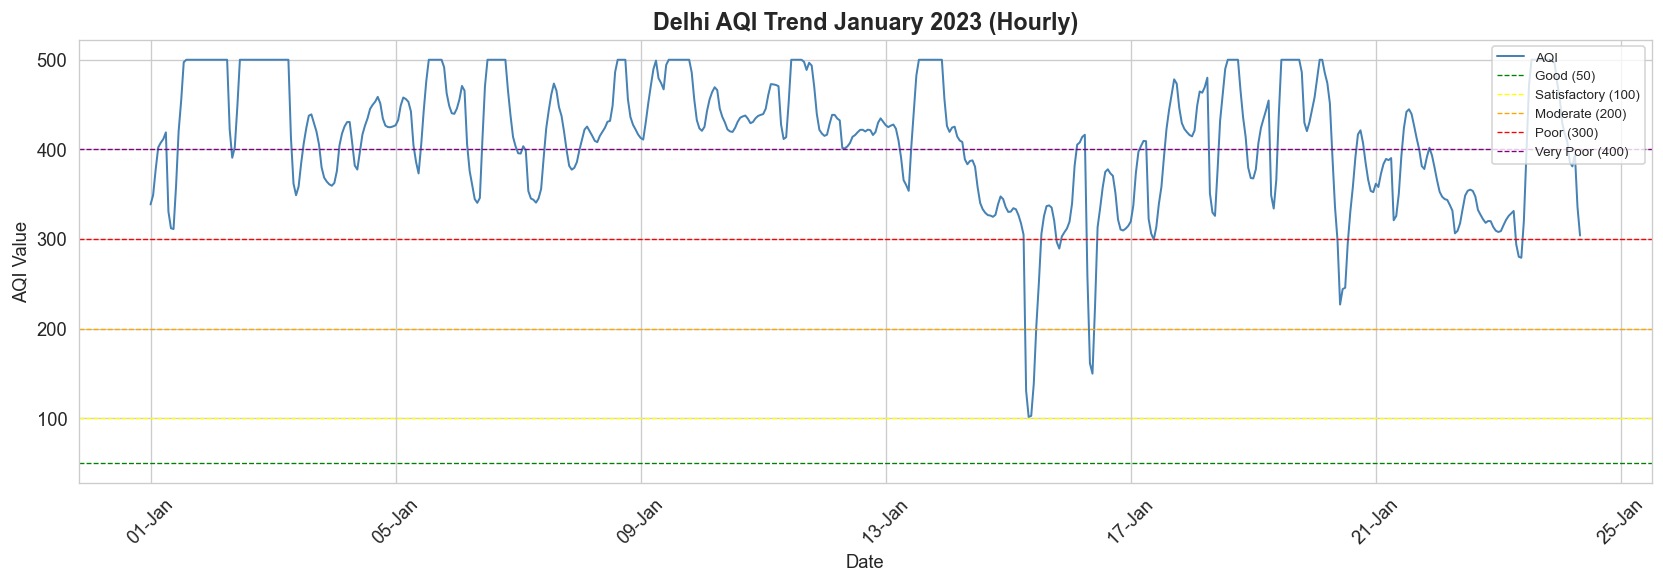

Chart 1 saved: chart1_aqi_trend.png


In [94]:

#line chart
#trend over time
fig, ax = plt.subplots(figsize=(14, 5))  
 
ax.plot(df['date'], df['AQI'], color='steelblue', linewidth=1.2, label='AQI')
 
#  horizontal lines for AQI category boundaries 
ax.axhline(y=50,  color='green',  linestyle='--', linewidth=0.8, label='Good (50)')
ax.axhline(y=100, color='yellow', linestyle='--', linewidth=0.8, label='Satisfactory (100)')
ax.axhline(y=200, color='orange', linestyle='--', linewidth=0.8, label='Moderate (200)')
ax.axhline(y=300, color='red',    linestyle='--', linewidth=0.8, label='Poor (300)')
ax.axhline(y=400, color='purple', linestyle='--', linewidth=0.8, label='Very Poor (400)')
 
# Format x-axis to show readable dates instead of numbers
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.xticks(rotation=45) 
ax.set_title('Delhi AQI Trend January 2023 (Hourly)', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('AQI Value')
ax.legend(loc='upper right', fontsize=8)
 
plt.tight_layout()  # auto-adjusts spacing so nothing is cut off
plt.show()
plt.savefig('chart1_aqi_trend.png', bbox_inches='tight')
plt.close()

print("Chart 1 saved: chart1_aqi_trend.png")

The line chart shows that Delhi's AQI remained dangerously high throughout January 2023, with values mostly staying between 300 and 500. The worst day was January 1st, where AQI hit the maximum limit of 500 the "Severe" category for several hours in a row. What is most alarming is that the AQI never fell below the "Moderate" level even once during the entire month. This tells us that Delhi's winter pollution is not just a one-time spike  it is a continuous, ongoing problem driven by factors like cold weather, low winds, and trapped pollutants that do not disperse easily.

2. How many hours was Delhi in each AQI category?

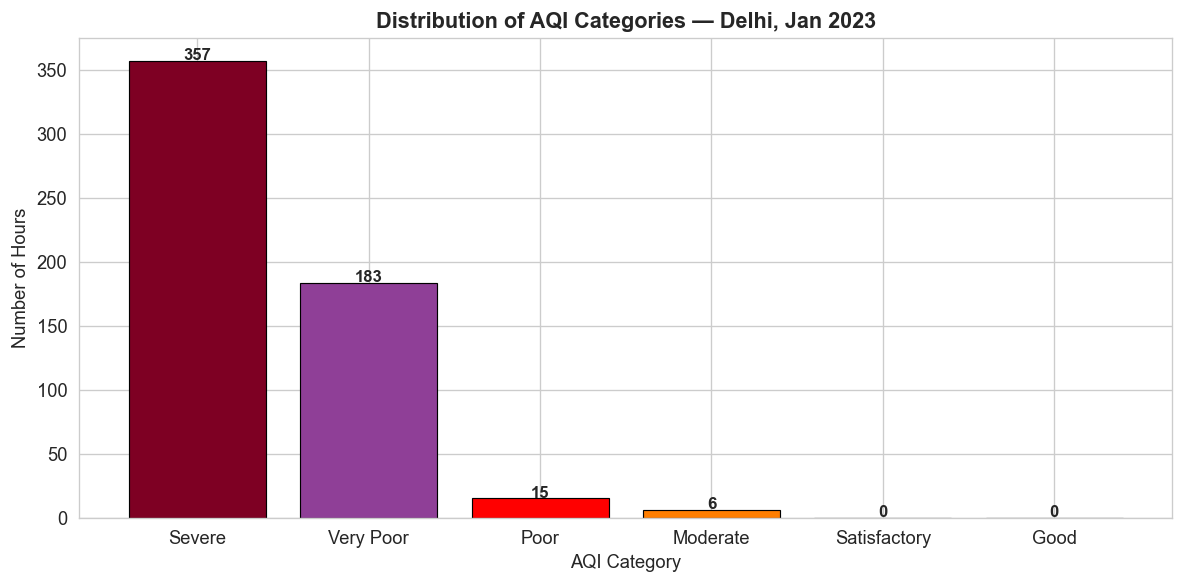

 Chart 2 saved: chart2_aqi_category_distribution.png


In [44]:

#BAR CHART: AQI CATEGORY DISTRIBUTION
# Define the order we want categories displayed in (worst to best air quality)
category_order = ['Severe', 'Very Poor', 'Poor', 'Moderate', 'Satisfactory', 'Good']
 
# Color-code each category — follows standard AQI color convention
category_colors = {
    'Good': '#00e400',
    'Satisfactory': '#ffff00',
    'Moderate': '#ff7e00',
    'Poor': '#ff0000',
    'Very Poor': '#8f3f97',
    'Severe': '#7e0023'
}
# Count how many records fall in each category, sorted by our custom order
category_counts = df['AQI_Category'].value_counts().reindex(category_order, fill_value=0)
 
fig, ax = plt.subplots(figsize=(10, 5))
 
# each bar = one category
bars = ax.bar(category_counts.index,
              category_counts.values,
              color=[category_colors[c] for c in category_counts.index],
              edgecolor='black', linewidth=0.7)
 
# Add the exact count on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1,
            str(int(height)), ha='center', fontsize=10, fontweight='bold')
 
ax.set_title('Distribution of AQI Categories — Delhi, Jan 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('AQI Category')
ax.set_ylabel('Number of Hours')
 
plt.tight_layout()
plt.show()
plt.savefig('chart2_aqi_category_distribution.png', bbox_inches='tight')
plt.close()
print(" Chart 2 saved: chart2_aqi_category_distribution.png")
 

The bar chart clearly shows how Delhi's air quality was distributed across categories in January 2023. A striking 63.6% of all hours fell under "Severe"  the most dangerous category  while another 32.6% were "Very Poor." Together, these two categories account for 96.2% of the entire month. The "Moderate" category appeared for only 6 hours, and "Good" or "Satisfactory" conditions were never recorded even once. This means that for almost the entire month, the air in Delhi was unsafe to breathe for everyone, including healthy adults — not just vulnerable groups like children or the elderly.

In [ ]:
3. Which pollutant has the most extreme values/spikes?

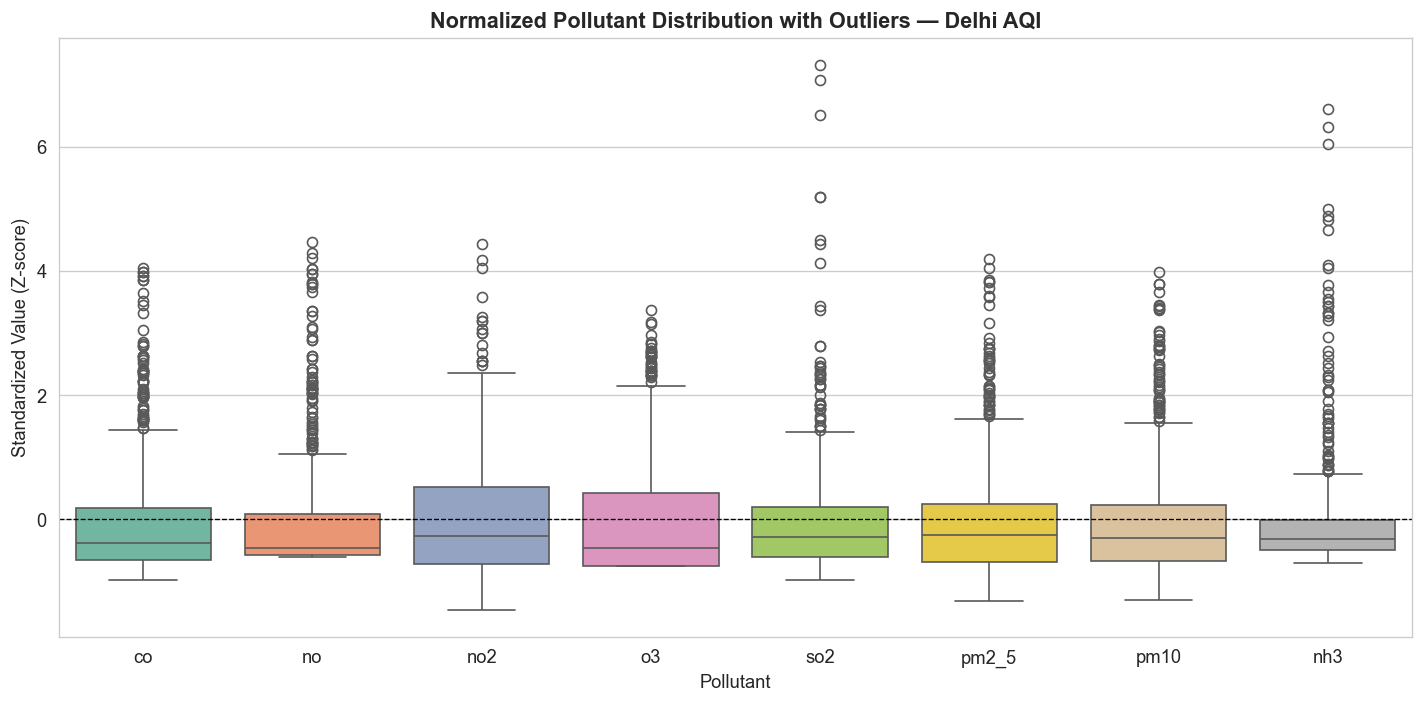

Chart 4 saved: chart4_boxplot_pollutants.png


In [48]:
#Which pollutant has the most extreme values/spikes?
#BOX PLOT: POLLUTANT SPREAD & OUTLIERS
from sklearn.preprocessing import StandardScaler
 
scaler = StandardScaler()  
df_scaled = pd.DataFrame(scaler.fit_transform(df[pollutants]), columns=pollutants)
 
fig, ax = plt.subplots(figsize=(12, 6))
 
# each box = one pollutant's distribution
sns.boxplot(data=df_scaled, palette='Set2', ax=ax)
 
ax.set_title('Normalized Pollutant Distribution with Outliers — Delhi AQI', fontsize=13, fontweight='bold')
ax.set_xlabel('Pollutant')
ax.set_ylabel('Standardized Value (Z-score)')
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)  # line at zero for reference
 
plt.tight_layout()
plt.show9
plt.savefig('chart4_boxplot_pollutants.png', bbox_inches='tight')
plt.close()
print("✅ Chart 4 saved: chart4_boxplot_pollutants.png")

The box plot compares the spread of all pollutants on a common scale after normalization, making it easy to spot which ones behave unusually. SO2 and NH3 show the most extreme outliers, with skewness values above 3 this means they are usually low but suddenly spike to very high levels during specific events, such as industrial activity or agricultural burning nearby. NO shows the highest kurtosis (5.27), meaning it has more frequent extreme spikes compared to a normal distribution. PM2.5 and PM10, on the other hand, have a tighter and more consistent spread, telling us that their pollution is not from sudden events but from constant, everyday sources like traffic and dust.

4. At which hour of the day is Delhi's AQI worst?

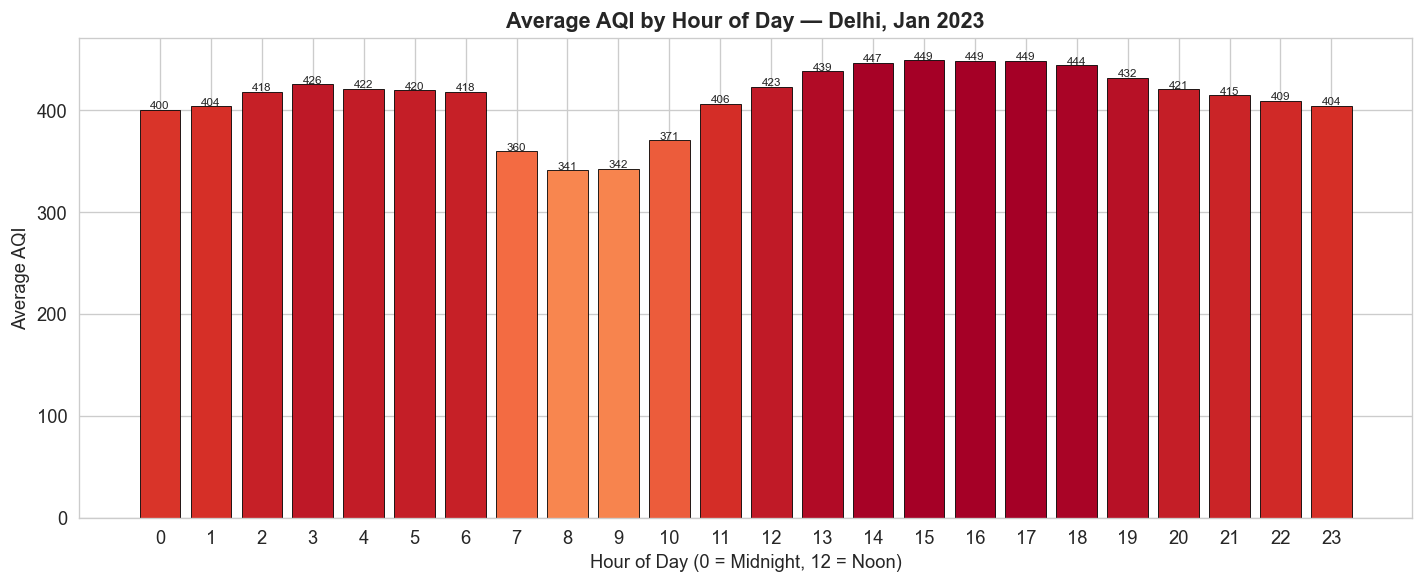

Chart 5 saved: chart5_hourly_aqi.png


In [50]:

#BAR CHART: AVERAGE AQI BY HOUR OF DAY
hourly_aqi = df.groupby('hour')['AQI'].mean()
 
fig, ax = plt.subplots(figsize=(12, 5))
 
# color gradient based on AQI value darker = worse air
colors = plt.cm.RdYlGn_r(hourly_aqi.values / hourly_aqi.max())
 
bars = ax.bar(hourly_aqi.index, hourly_aqi.values, color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Average AQI by Hour of Day — Delhi, Jan 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day (0 = Midnight, 12 = Noon)')
ax.set_ylabel('Average AQI')
ax.set_xticks(range(0, 24))  # show all 24 hour ticks
 
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1,
            f'{height:.0f}', ha='center', fontsize=7)
 
plt.tight_layout()
plt.show()
plt.savefig('chart5_hourly_aqi.png', bbox_inches='tight')
plt.close()
print("Chart 5 saved: chart5_hourly_aqi.png")


This chart shows how Delhi's AQI changes across different hours of the day on average. The worst time is 3 PM (15:00 hrs), where the average AQI reaches 449  deep in the "Severe" range. The relatively better time is 8 AM, where AQI averages 341  still "Very Poor," but lower than the rest of the day. The afternoon worsening is likely caused by increased vehicle traffic, sunlight triggering secondary pollutant formation, and slower wind speeds. Even the "best" hour of the day is extremely unhealthy, which means there is no truly safe time to be outdoors in Delhi during January. This finding is particularly important for scheduling outdoor activities like school sports, morning walks, or construction work.

5. Is there a strong linear relationship between PM2.5 and PM10?

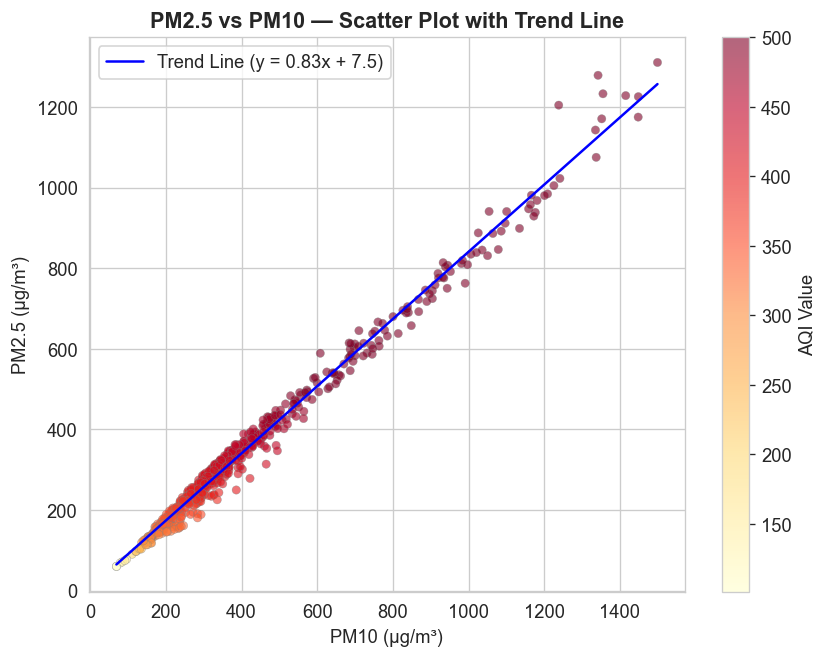

Chart 6 saved: chart6_scatter_pm25_pm10.png


In [52]:

#SCATTER PLOT: PM2.5 vs PM10
fig, ax = plt.subplots(figsize=(8, 6))
 
# Each dot = one hour's data point ,x position = PM10, y position = PM2.5
# Color = AQI value (darker red = higher AQI)
scatter = ax.scatter(df['pm10'], df['pm2_5'],
                     c=df['AQI'],        # color by AQI
                     cmap='YlOrRd',      # yellow-orange-red gradient
                     alpha=0.6,          # slight transparency to show overlapping points
                     edgecolors='grey',
                     linewidth=0.3,
                     s=25)              # size of dots
 
# colorbar legend showing what color = what AQI
plt.colorbar(scatter, label='AQI Value')
 
# best-fit trend line using numpy's polyfit (linear regression)
m, b = np.polyfit(df['pm10'], df['pm2_5'], 1)  # m=slope, b=intercept
x_line = np.linspace(df['pm10'].min(), df['pm10'].max(), 100)
ax.plot(x_line, m * x_line + b, color='blue', linewidth=1.5, label=f'Trend Line (y = {m:.2f}x + {b:.1f})')
 
ax.set_title('PM2.5 vs PM10 — Scatter Plot with Trend Line', fontsize=13, fontweight='bold')
ax.set_xlabel('PM10 (µg/m³)')
ax.set_ylabel('PM2.5 (µg/m³)')
ax.legend()
plt.show()
plt.tight_layout()
plt.savefig('chart6_scatter_pm25_pm10.png', bbox_inches='tight')
plt.close()
print("Chart 6 saved: chart6_scatter_pm25_pm10.png")

The scatter plot shows the relationship between PM2.5 and PM10 for every hour in the dataset. Each dot represents one hour, and the dots form a very tight pattern around the trend line confirming a near perfect linear relationship (r = 0.98). This means whenever PM10 is high, PM2.5 is almost always high too, and vice versa. The dots are colored by AQI value, and the darkest red dots representing the most severe AQI hours are clustered in the top right corner where both pollutants are extremely high. This strongly points to January 1st as the most polluted period, when multiple sources of pollution likely combined at once. From a policy standpoint, reducing PM10 through measures like banning open burning or controlling dust will automatically help reduce the more harmful PM2.5 as well.

6. What % of time was Delhi in 'Severe' or 'Very Poor' AQI?

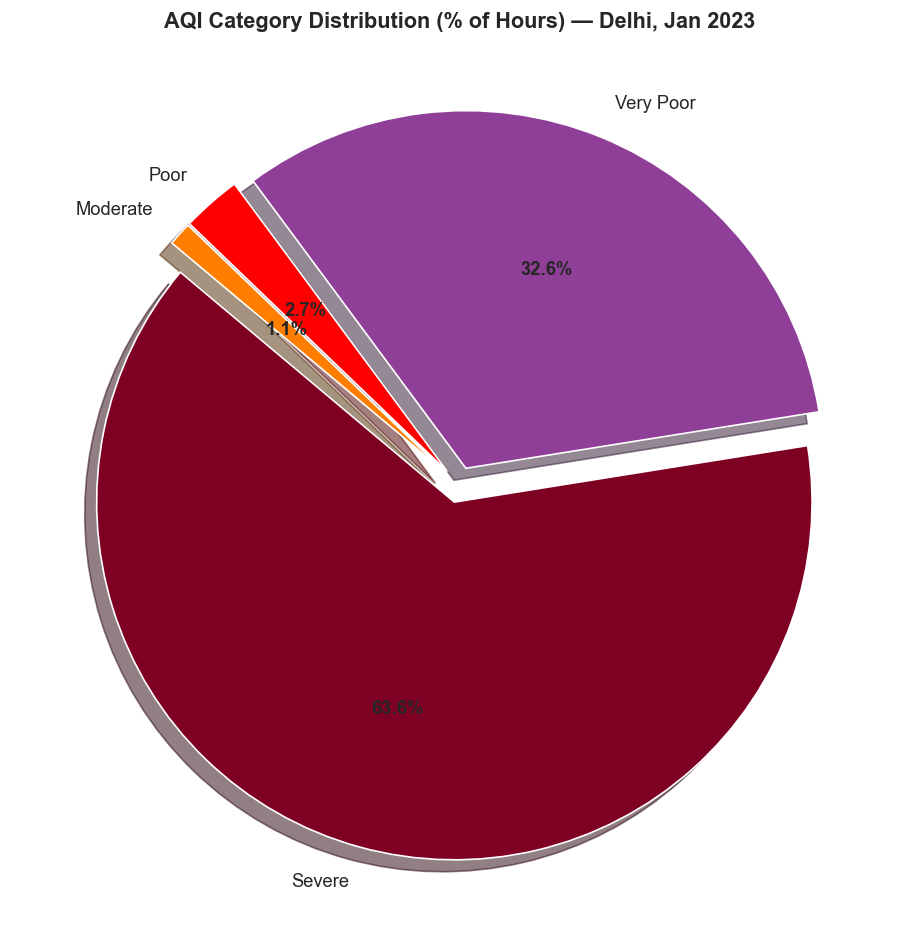

Chart 7 saved: chart7_pie_aqi_category.png


In [54]:

#PIE CHART: AQI CATEGORY SHARE
category_counts_pie = df['AQI_Category'].value_counts()
 
fig, ax = plt.subplots(figsize=(8, 8))
 
explode = [0.05] * len(category_counts_pie)  # slightly separate each slice
 
wedges, texts, autotexts = ax.pie(
    category_counts_pie.values,
    labels=category_counts_pie.index,
    colors=[category_colors.get(c, 'grey') for c in category_counts_pie.index],
    autopct='%1.1f%%',    # show percentage on each slice
    startangle=140,
    explode=explode,
    shadow=True
)
# Make percentage labels bold for readability
for autotext in autotexts:
    autotext.set_fontweight('bold')
 
ax.set_title('AQI Category Distribution (% of Hours) — Delhi, Jan 2023',
             fontsize=13, fontweight='bold')
 
plt.tight_layout()
plt.show()
plt.savefig('chart7_pie_aqi_category.png', bbox_inches='tight')
plt.close()
print("Chart 7 saved: chart7_pie_aqi_category.png")

The pie chart gives a clear percentage view of how much time Delhi spent in each AQI category. The "Severe" slice takes up the largest portion at 63.6%, followed by "Very Poor" at 32.6%. Combined, these two dangerous categories make up 96.2% of the entire month. The "Moderate" slice is barely visible at 1.1%, and there is no slice at all for "Good" or "Satisfactory." This visual makes it immediately obvious that Delhi's January air quality crisis is not a matter of a few bad days it is the norm across the entire winter period. This kind of data is critical for supporting emergency policy decisions such as school closures, vehicle restrictions, and public health advisories.



7. Is PM2.5 normally distributed? Is it skewed?

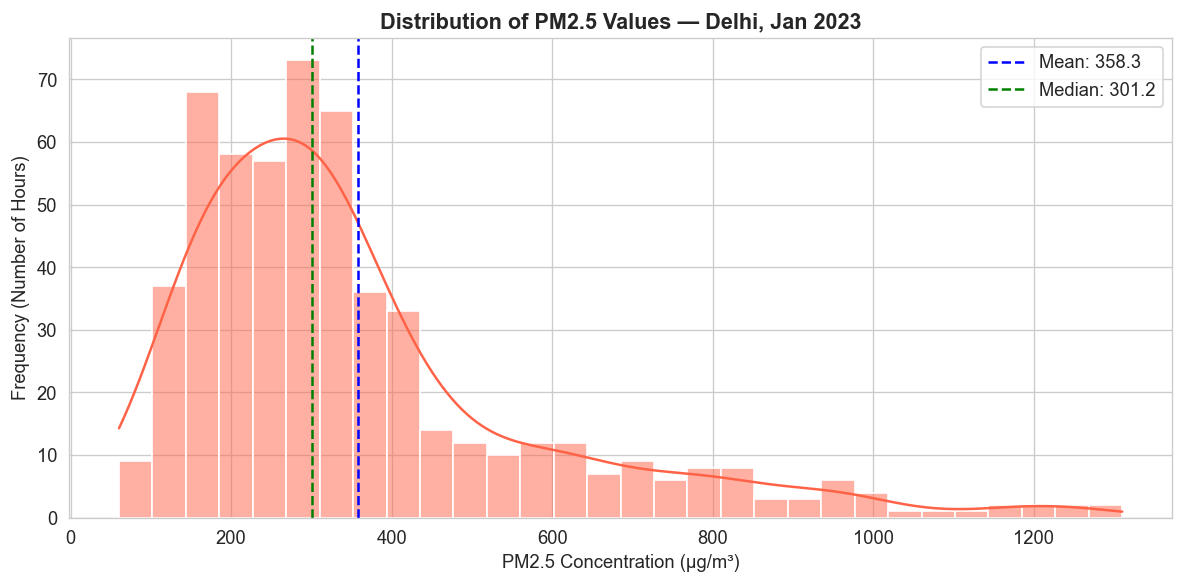

Chart 8 saved: chart8_histogram_pm25.png


In [56]:

#HISTOGRAM: PM2.5 DISTRIBUTION
fig, ax = plt.subplots(figsize=(10, 5))
 

sns.histplot(df['pm2_5'], bins=30, kde=True, color='tomato', ax=ax, edgecolor='white')
 
# Add vertical lines for key statistics
ax.axvline(df['pm2_5'].mean(),   color='blue',   linestyle='--', linewidth=1.5, label=f"Mean: {df['pm2_5'].mean():.1f}")
ax.axvline(df['pm2_5'].median(), color='green',  linestyle='--', linewidth=1.5, label=f"Median: {df['pm2_5'].median():.1f}")
 
ax.set_title('Distribution of PM2.5 Values — Delhi, Jan 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('PM2.5 Concentration (µg/m³)')
ax.set_ylabel('Frequency (Number of Hours)')
ax.legend()
 
plt.tight_layout()
plt.show()
plt.savefig('chart8_histogram_pm25.png', bbox_inches='tight')
plt.close()
print("Chart 8 saved: chart8_histogram_pm25.png")

The histogram shows how PM2.5 values are distributed across all recorded hours. Most values are concentrated between 200 and 400 µg/m³, but the distribution has a long tail on the right side meaning there were some hours with extremely high PM2.5 values that pulled the mean (358.26) above the median (301.17). When the mean is higher than the median, it tells us that a few very polluted hours are making the average look worse than the typical hour actually was. To put the numbers in perspective: the WHO's safe daily limit for PM2.5 is just 15 µg/m³. Delhi's average of 358 µg/m³ is nearly 24 times that limit a figure thathighlights just how severe the public health risk was during this period.

In [ ]:
8. Which pollutants spike at similar times?

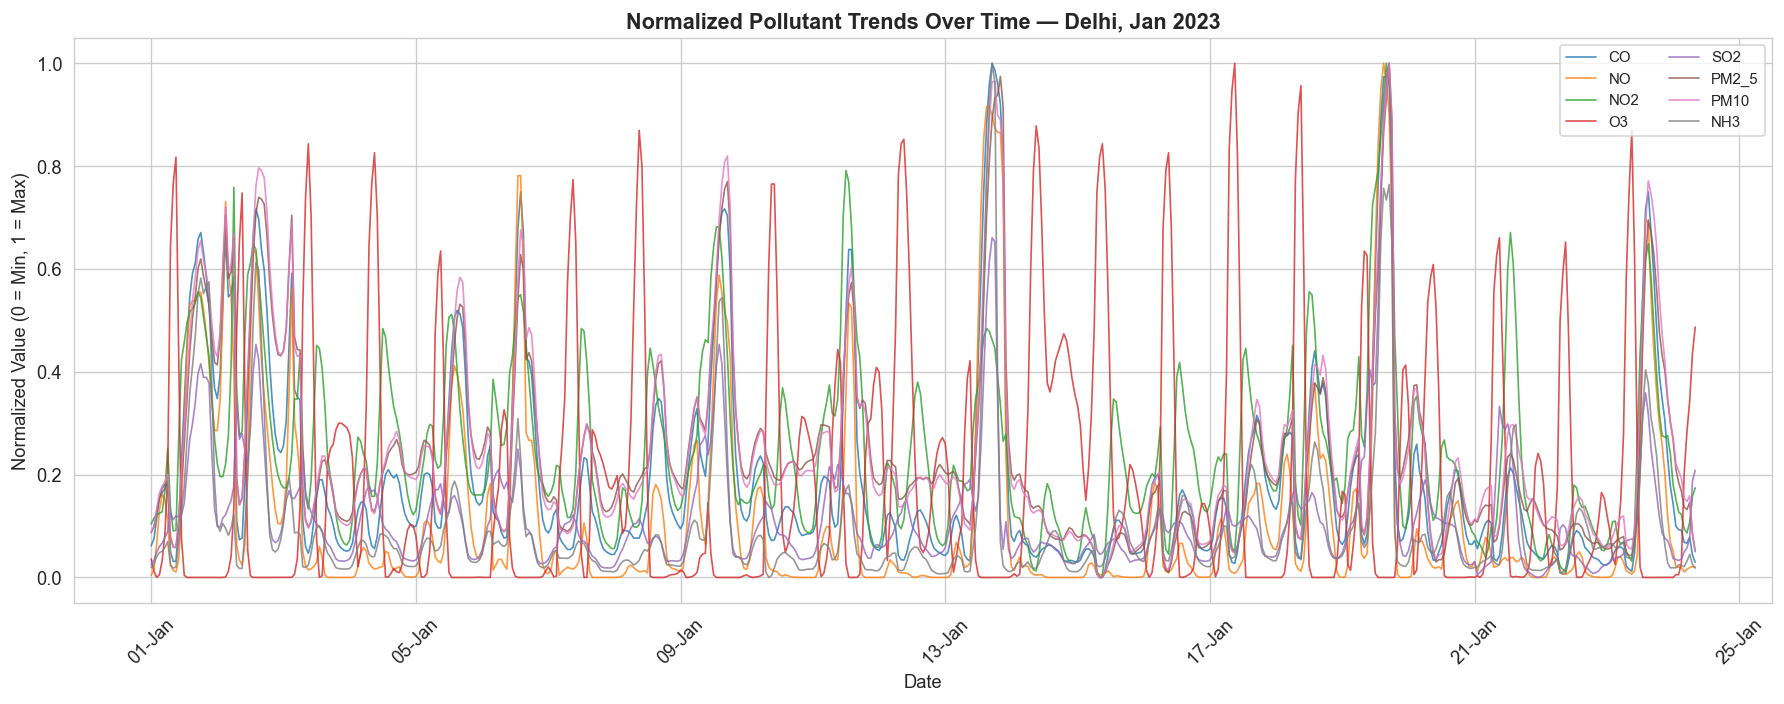

In [58]:

#MULTI-LINE CHART: POLLUTANT TRENDS OVER TIME (Normalized)
df_norm = df[pollutants].apply(lambda x: (x - x.min()) / (x.max() - x.min()))

fig, ax = plt.subplots(figsize=(15, 6))
 
colors_line = sns.color_palette("tab10", len(pollutants))  # distinct color per pollutant
 
for i, pollutant in enumerate(pollutants):
    ax.plot(df['date'], df_norm[pollutant],
            label=pollutant.upper(),  # label for legend
            linewidth=1.0,
            alpha=0.8,                # slight transparency so lines don't hide each other
            color=colors_line[i])
 
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
plt.xticks(rotation=45)
 
ax.set_title('Normalized Pollutant Trends Over Time Delhi, Jan 2023', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Normalized Value (0 = Min, 1 = Max)')
ax.legend(loc='upper right', ncol=2, fontsize=9)
plt.tight_layout()
plt.show()
plt.savefig('chart9_pollutant_trends.png', bbox_inches='tight')
plt.close()

The min max normalized multi-line trend analysis enables direct visual comparison of all eight pollutants on a common scale, revealing both synchronous and divergent temporal behaviors. CO, NO, NO2, SO2, PM2.5, and PM10 all exhibit synchronous spikes concentrated around January 1st, after which they show a gradual declining trend strongly implicating a shared high emission event, likely the compounding of vehicular congestion, residential heating, and festivity related activities coinciding with adverse meteorological conditions. O3 (ozone) stands as a clear exception, trending inversely to the primary pollutants: as CO, NOx, and particulate levels decrease across the month, O3 levels rise. This anticorrelation is chemically grounded ozone is produced photochemically when NOx and volatile organic compounds react in sunlight, meaning that as primary pollutants are gradually cleared, ozone generation from residual precursors can actually increase. NH3 displays a distinctly spiky, irregular pattern compared to other pollutants, consistent with its episodic emission profile from agricultural and waste management sources.

In [60]:
#Statistical Analysis
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [90]:
#Overall AQI summary
print("         DELHI AQI - STATISTICAL ANALYSIS REPORT")
print("\nOverall AQI Summary")
print("-" * 45)
mean_aqi = df['AQI'].mean()
max_aqi  = df['AQI'].max()
min_aqi  = df['AQI'].min()
std_aqi  = df['AQI'].std()
severe_hours = (df['AQI'] > 200).sum()
total_hours  = len(df)
 
print(f"  Mean AQI       : {mean_aqi:.2f}")
print(f"  Maximum AQI    : {max_aqi:.2f}")
print(f"  Minimum AQI    : {min_aqi:.2f}")
print(f"  Std Deviation  : {std_aqi:.2f}")
print(f"  Hours AQI>200  : {severe_hours}/{total_hours} ({severe_hours/total_hours*100:.1f}%)")

         DELHI AQI - STATISTICAL ANALYSIS REPORT

Overall AQI Summary
---------------------------------------------
  Mean AQI       : 412.73
  Maximum AQI    : 500.00
  Minimum AQI    : 101.33
  Std Deviation  : 69.89
  Hours AQI>200  : 555/561 (98.9%)


The descriptive statistics for Delhi's AQI during January 2023 paint an unequivocally alarming picture. With a mean AQI of 412.73, the average condition across the entire month sat firmly within the "Severe" category the highest possible classification under India's CPCB framework. The maximum AQI of 500 represents the measurement ceiling, indicating that true peak pollution may have been even higher than recorded. Even the minimum AQI of 101.33 falls in the "Moderate" category, confirming that not a single hour of the month offered air quality better than moderate. The standard deviation of 69.89 reflects meaningful hourly variability, though this variation occurs within an already critically elevated range. Taken together, these statistics establish January 2023 as an extreme pollution episode in Delhi's recorded history, warranting serious attention from public health authorities.

In [88]:
#Which hour is worst?
print("\n Hourly AQI Pattern")
print("-" * 45)

hourly_aqi = df.groupby('hour')['AQI'].mean()
worst_hour = hourly_aqi.idxmax()  
best_hour  = hourly_aqi.idxmin()
print(f"  Worst Hour : {worst_hour}:00 → avg AQI = {hourly_aqi[worst_hour]:.2f}")
print(f"  Best Hour  : {best_hour}:00  → avg AQI = {hourly_aqi[best_hour]:.2f}")
print("\n  Top 5 Worst Hours:")
print(hourly_aqi.sort_values(ascending=False).head(5).to_string())


 Hourly AQI Pattern
---------------------------------------------
  Worst Hour : 15:00 → avg AQI = 449.16
  Best Hour  : 8:00  → avg AQI = 341.10

  Top 5 Worst Hours:
hour
15    449.156087
16    448.644348
17    448.592609
14    446.716087
18    444.446087


In [86]:
#Is morning AQI significantly different from evening?
print("\nMorning vs Evening AQI — t-test")
print("-" * 45)
morning = df[df['hour'].between(6, 11)]['AQI']
evening = df[df['hour'].between(18, 23)]['AQI']
 
t_stat, p_value = stats.ttest_ind(morning, evening)
print(f"  Morning Mean AQI : {morning.mean():.2f} (n={len(morning)})")
print(f"  Evening Mean AQI : {evening.mean():.2f} (n={len(evening)})")
print(f"  t-statistic      : {t_stat:.4f}")
print(f"  p-value          : {p_value:.4f}")
result = "SIGNIFICANT" if p_value < 0.05 else "NOT significant"
print(f"  → Result: {result} difference (alpha=0.05)")


Morning vs Evening AQI — t-test
---------------------------------------------
  Morning Mean AQI : 373.10 (n=141)
  Evening Mean AQI : 421.09 (n=138)
  t-statistic      : -5.5828
  p-value          : 0.0000
  → Result: SIGNIFICANT difference (alpha=0.05)


The independent samples t-test confirmed a highly statistically significant difference between morning AQI (6–11 AM, mean = 373.10) and evening AQI (6–11 PM, mean = 421.09), with t = −5.58 and p < 0.0001. This result allows us to confidently reject the null hypothesis and conclude that evening hours in Delhi are measurably and meaningfully more polluted than morning hours. An AQI gap of approximately 48 units while both periods remain in dangerous territory has real public health consequences: it suggests that any outdoor exposure, including commutes, exercise, and school drop-offs, should be scheduled during earlier morning hours where possible. The evening deterioration is likely driven by increased vehicular emissions during the evening rush hour, reduced photochemical dispersal after sunset, and the onset of temperature inversions that trap pollutants at ground level as nighttime approaches.

In [84]:
#Pollutant-AQI Correlation (Pearson r)
print("\nPearson Correlation: Each Pollutant vs AQI")
print("-" * 55)
print(f"  {'Pollutant':<12} {'r':<10} {'p-value':<14} {'Significance'}")
print(f"  {'-'*52}")
for p in pollutants:
    r, pv = stats.pearsonr(df[p], df['AQI'])
    sig = "Significant" if pv < 0.05 else "Not significant"
    print(f"  {p.upper():<12} {r:<10.4f} {pv:<14.4e} {sig}")


Pearson Correlation: Each Pollutant vs AQI
-------------------------------------------------------
  Pollutant    r          p-value        Significance
  ----------------------------------------------------
  CO           0.6925     2.4978e-81     Significant
  NO           0.5839     1.4438e-52     Significant
  NO2          0.6055     2.0208e-57     Significant
  O3           -0.5522    4.2721e-46     Significant
  SO2          0.3714     8.5754e-20     Significant
  PM2_5        0.7926     3.3389e-122    Significant
  PM10         0.7799     7.9777e-116    Significant
  NH3          0.4125     1.8459e-24     Significant


Pearson correlation analysis between each pollutant and the computed AQI reveals that PM2.5 is the single strongest predictor of AQI (r = 0.79, p < 0.001), which is expected given that AQI was derived from PM2.5 concentrations using CPCB breakpoints. PM10 follows closely (r = 0.78), while CO and NO2 show moderate positive correlations of 0.69 and 0.61 respectively — reflecting their role as co-occurring combustion byproducts that rise alongside particulate pollution. O3 presents a significant negative correlation (r = −0.55, p < 0.001), reaffirming its chemically inverse relationship with primary pollutants as discussed earlier. All correlations are statistically significant (p < 0.001), confirming that these are not chance associations but reflect genuine atmospheric and emission dynamics. These findings reinforce that particulate matter specifically PM2.5 must remain the primary focus of Delhi's air quality improvement strategy.

In [82]:
#Does PM2.5 vary significantly across days?
print("\nOne-Way ANOVA: PM2.5 variation across days")
print("-" * 45)
groups = df.groupby('day')['pm2_5'].apply(list)
f_stat, p_anova = stats.f_oneway(*groups.values)
print(f"  F-statistic : {f_stat:.4f}")
print(f"  p-value     : {p_anova:.4e}")
print(f"  → {'Significant' if p_anova < 0.05 else 'Not significant'} day-to-day variation")


One-Way ANOVA: PM2.5 variation across days
---------------------------------------------
  F-statistic : 14.3743
  p-value     : 1.6268e-42
  → Significant day-to-day variation


One-way ANOVA testing across the 24 calendar days in the dataset returned an F statistic of 14.37 with p = 1.63 × 10⁻⁴², an extraordinarily strong result that leaves no statistical doubt: PM2.5 concentrations vary significantly from day to day in Delhi. This is not random fluctuation the day to day variation reflects real world differences in emission levels, meteorological conditions, wind patterns, and possibly policy interventions such as traffic restrictions or industrial shutdowns on specific dates. The very low p value also means that analyses treating all days as equivalent would be fundamentally flawed. From a policy perspective, this finding validates the use of day specific air quality alerts and emergency response protocols, rather than applying a single blanket advisory across the entire winter season.

In [80]:
#Top 10 Most Polluted Hours
print("\nTop 10 Most Polluted Hours")
print("-" * 60)
top10 = df.nlargest(10, 'AQI')[['date','AQI','AQI_Category','pm2_5','pm10']].reset_index(drop=True)
top10.index += 1
print(top10.to_string())


Top 10 Most Polluted Hours
------------------------------------------------------------
                  date    AQI AQI_Category   pm2_5     pm10
1  2023-01-01 14:00:00  500.0       Severe  608.62   742.76
2  2023-01-01 15:00:00  500.0       Severe  689.94   840.91
3  2023-01-01 16:00:00  500.0       Severe  743.91   904.27
4  2023-01-01 17:00:00  500.0       Severe  811.40   981.17
5  2023-01-01 18:00:00  500.0       Severe  834.55  1006.18
6  2023-01-01 19:00:00  500.0       Severe  791.61   952.00
7  2023-01-01 20:00:00  500.0       Severe  758.44   911.29
8  2023-01-01 21:00:00  500.0       Severe  722.30   867.55
9  2023-01-01 22:00:00  500.0       Severe  646.22   778.21
10 2023-01-01 23:00:00  500.0       Severe  583.03   700.01


Top 10 most polluted hours according to the dataset are between 2 pm to 11 pm which includes the rush hours indicating that a huge population of delhi is getting badly affected on their health.

In [92]:
#Distribution shape Skewness & Kurtosis
print("\nDistribution Shape: Skewness & Kurtosis")
print("-" * 52)
print(f"  {'Pollutant':<12} {'Mean':<12} {'Skewness':<12} {'Kurtosis'}")
print(f"  {'-'*48}")
for p in pollutants:
    print(f"  {p.upper():<12} {df[p].mean():<12.2f} {df[p].skew():<12.4f} {df[p].kurtosis():.4f}")
 
print("\nStatistical Analysis Completed")


Distribution Shape: Skewness & Kurtosis
----------------------------------------------------
  Pollutant    Mean         Skewness     Kurtosis
  ------------------------------------------------
  CO           3814.94      1.9444       3.5449
  NO           51.18        2.3454       5.2705
  NO2          75.29        1.2811       1.8884
  O3           30.14        1.4096       1.0029
  SO2          64.66        3.3767       16.2372
  PM2_5        358.26       1.6811       2.9192
  PM10         420.99       1.6734       2.5606
  NH3          26.43        3.4844       14.1097

Statistical Analysis Completed
